# **Introduction**

In this notebook, My focus is on learning and implementing **probabilistic models** using Bayesian techniques. The goal is to apply **Bayesian Linear Regression**, **Bayesian Logistic Regression**, and **Gaussian Process Regression** on real-world datasets. These models not only help in prediction but also allow us to capture and understand the **uncertainty** in the predictions, which is a major advantage over traditional methods.

For this task, I am using the following datasets:
- **Boston** dataset (from ISLP) for Bayesian Linear Regression
- **Heart Disease** dataset (from ISLP) for Bayesian Logistic Regression
- **Auto MPG** dataset (from ISLP) for Gaussian Process Regression

To keep the code clean and reusable, I have created a separate Python module file named **Probabilistic_models.py**. This file contains all the modeling functions, so I can simply import and use them in this notebook for training and evaluation.

The notebook is structured to first explore and clean each dataset, then apply the corresponding Bayesian model, and finally visualize the results along with uncertainty using plots. This work also helps me understand the concepts from PML (Probabilistic Machine Learning) books, especially chapters related to Bayesian inference, MCMC, Variational Inference (VI), and Gaussian Processes.

At the end, I will also prepare this notebook for **peer code review**. This includes making the code readable, modular, and well documented with explanations.



## **Introduction to Bayesian Modeling**

Bayesian modeling is a probabilistic approach where we use **Bayes' theorem** to update our beliefs about unknown quantities based on observed data. Instead of predicting single values, Bayesian methods provide **distributions**, which help us understand the **uncertainty** in our predictions.

At the core is Bayes’ rule:

$$
p(H \mid Y) = \frac{p(H) \cdot p(Y \mid H)}{p(Y)}
$$

This allows us to compute the **posterior** (updated belief) using a **prior** (initial belief) and a **likelihood** (how well the data supports each hypothesis).

In this notebook, we implement and analyze:
- **Bayesian Linear Regression** (on the Boston dataset)
- **Bayesian Logistic Regression** (on the Heart Disease dataset)
- **Gaussian Processes** (on the Auto MPG dataset)

I use PyMC or NumPyro to build the models and visualize uncertainty using posterior distributions and prediction intervals.



Dataset Overview
   Age  Sex     ChestPain  RestBP  Chol  Fbs  RestECG  MaxHR  ExAng  Oldpeak  \
0   63    1       typical     145   233    1        2    150      0      2.3   
1   67    1  asymptomatic     160   286    0        2    108      1      1.5   
2   67    1  asymptomatic     120   229    0        2    129      1      2.6   
3   37    1    nonanginal     130   250    0        0    187      0      3.5   
4   41    0    nontypical     130   204    0        2    172      0      1.4   

   Slope   Ca        Thal  AHD  
0      3  0.0       fixed   No  
1      2  3.0      normal  Yes  
2      2  2.0  reversable  Yes  
3      3  0.0      normal   No  
4      1  0.0      normal   No  
Shape: (303, 14)

Column Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        303 non-null    int64  
 1   Sex        303 non-null    int64  
 2   Che

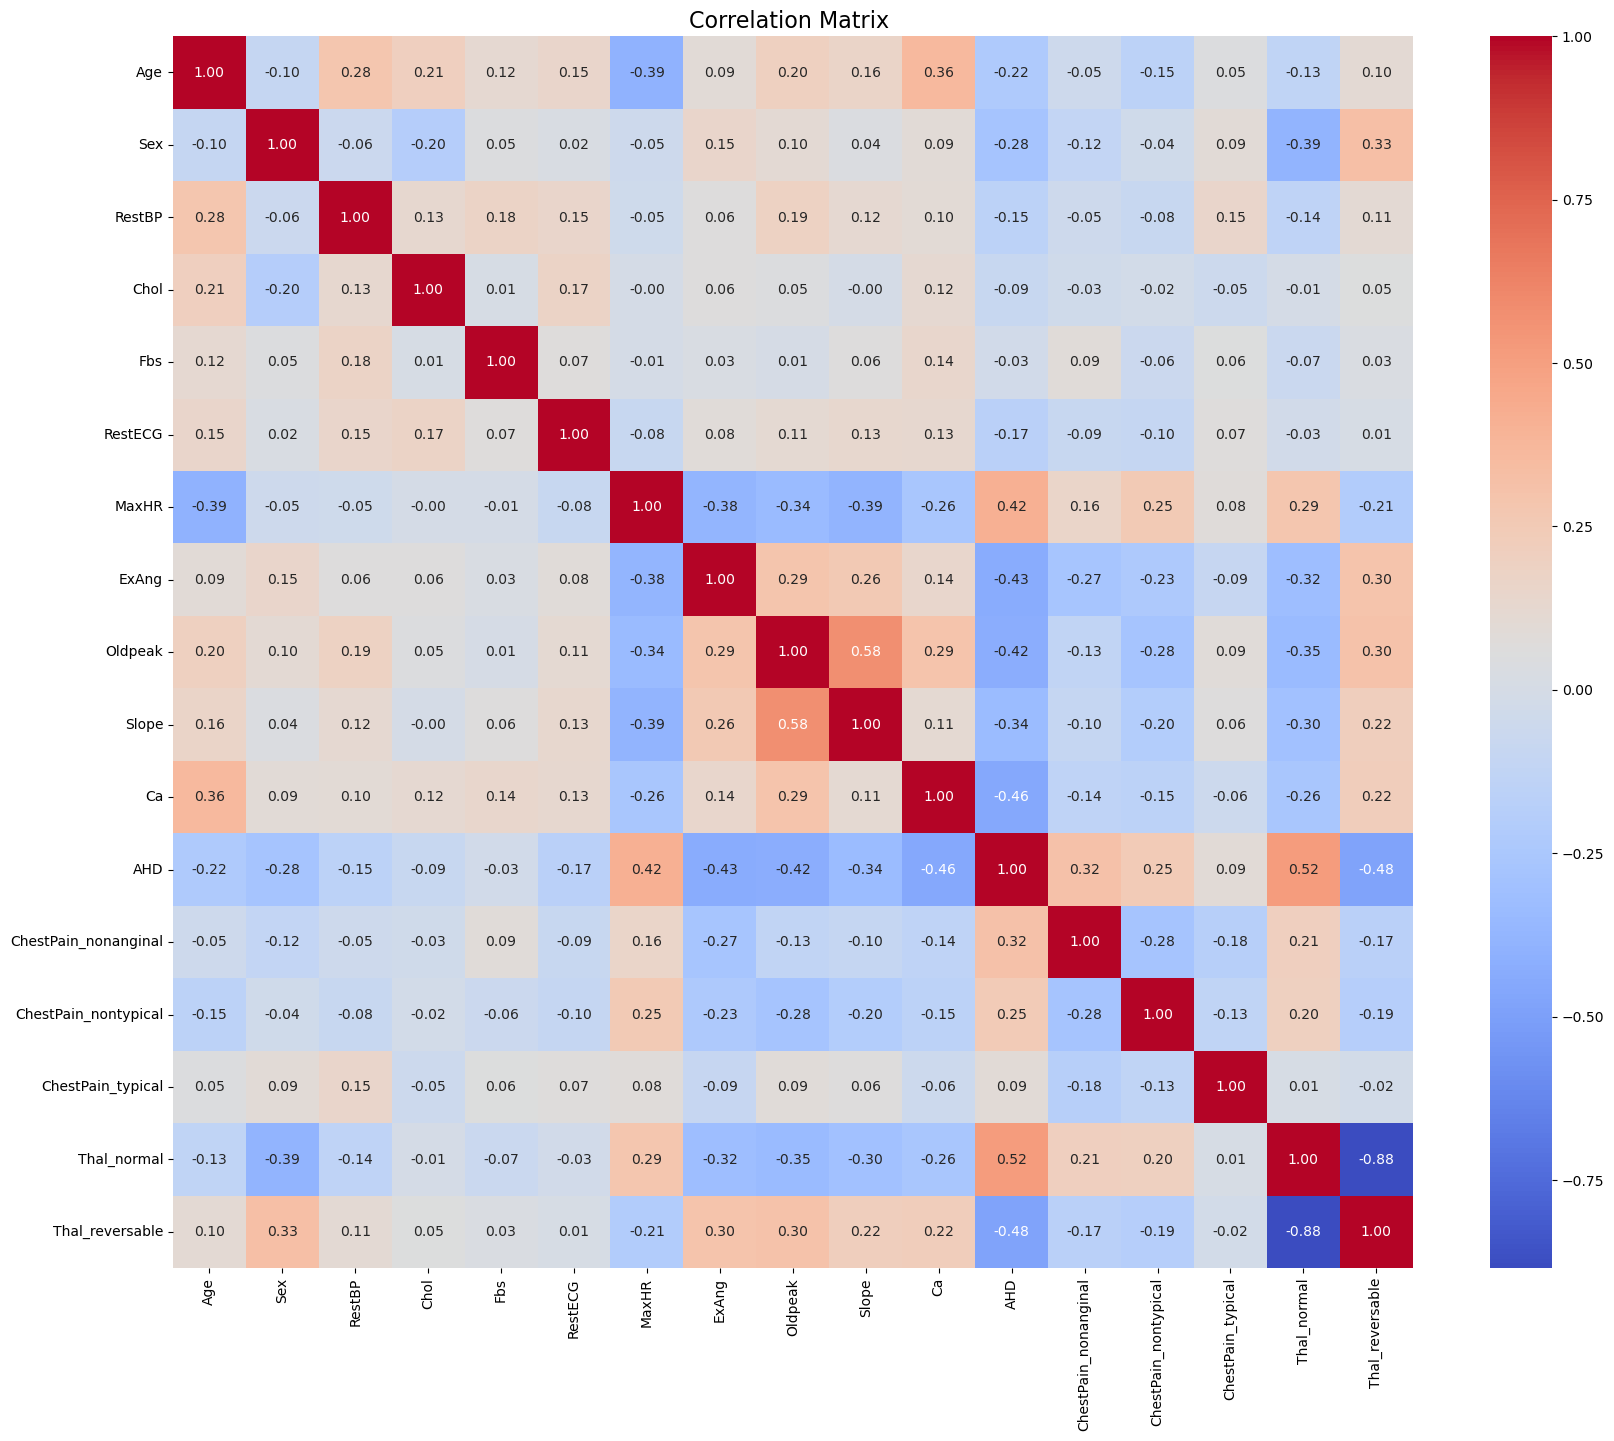


Correlation with Target (response)
AHD                     1.000000
Thal_normal             0.520628
MaxHR                   0.417167
ChestPain_nonanginal    0.315141
ChestPain_nontypical    0.248683
ChestPain_typical       0.088806
Fbs                    -0.025264
Chol                   -0.085164
RestBP                 -0.150825
RestECG                -0.169202
Age                    -0.223120
Sex                    -0.276816
Slope                  -0.339213
Oldpeak                -0.424510
ExAng                  -0.431894
Ca                     -0.457598
Thal_reversable        -0.480582
Name: AHD, dtype: float64

Response Variable: AHD
Predictor Variables (16): ['Age', 'Sex', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR', 'ExAng', 'Oldpeak', 'Slope', 'Ca', 'ChestPain_nonanginal', 'ChestPain_nontypical', 'ChestPain_typical', 'Thal_normal', 'Thal_reversable']


In [1]:
import pandas as pd
from All_Regression_models import *
from Probabilistic_models import *
import All_Regression_models
import Probabilistic_models


# Load the dataset
Heart= pd.read_csv('All Sample Data/Sample Data/Heart.csv')
response='AHD'
df=All_Regression_models.EDA_processing(Heart,response)
# Separate predictors (X) and target (y)
X = df.drop('AHD', axis=1)
y = df['AHD']

# Optional: Get list of predictor names
predictors= X.columns.tolist()



Rescaled Coefficients (in original feature scale):
Bias (Intercept): 1.0788
Coefficient for Age: -0.0073
Coefficient for Sex: -0.1869
Coefficient for RestBP: -0.0025
Coefficient for Chol: -0.0008
Coefficient for Fbs: 0.0128
Coefficient for RestECG: -0.0489
Coefficient for MaxHR: 0.0042
Coefficient for ExAng: -0.2533
Coefficient for Oldpeak: -0.1009
Coefficient for Slope: -0.1396
Coefficient for Ca: -0.1551
Coefficient for ChestPain_nonanginal: 0.2079
Coefficient for ChestPain_nontypical: 0.1716
Coefficient for ChestPain_typical: 0.1586
Coefficient for Thal_normal: 0.2541
Coefficient for Thal_reversable: -0.2474

Final Log-likelihood (on training set): -0.5755

Train Accuracy: 0.83
Test Accuracy: 0.84
F1 Score (Test): 0.84

Confusion Matrix (Test):
 [[24  8]
 [ 2 27]]
Classification Report (Test):
               precision    recall  f1-score   support

           0       0.92      0.75      0.83        32
           1       0.77      0.93      0.84        29

    accuracy              

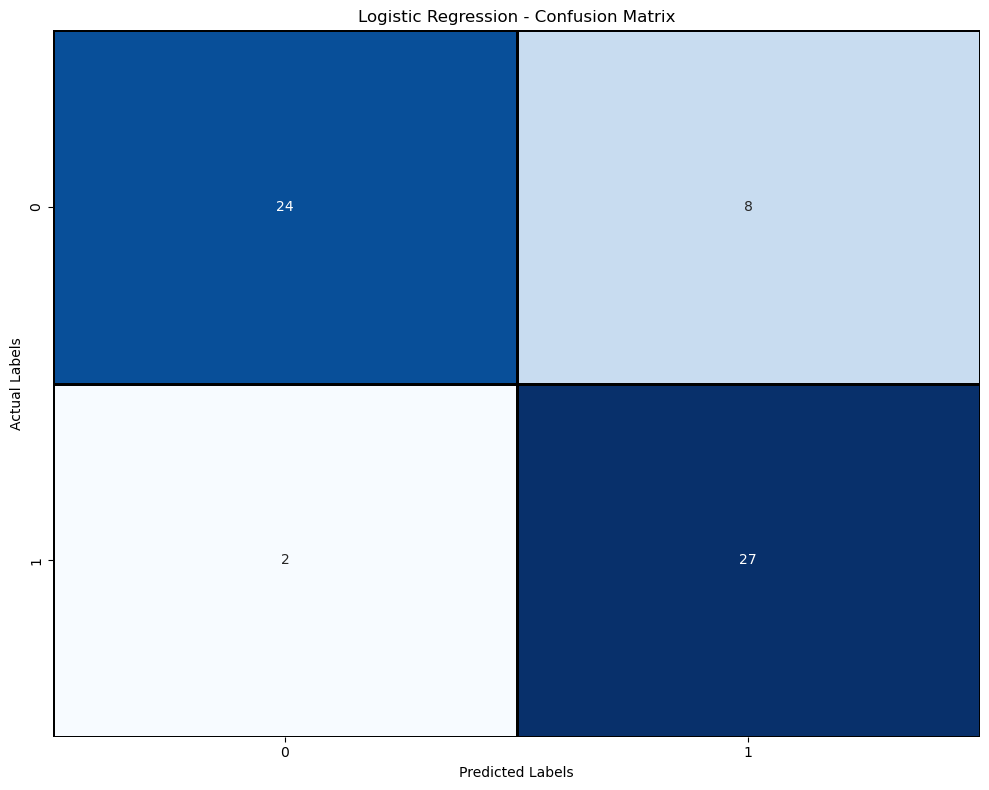

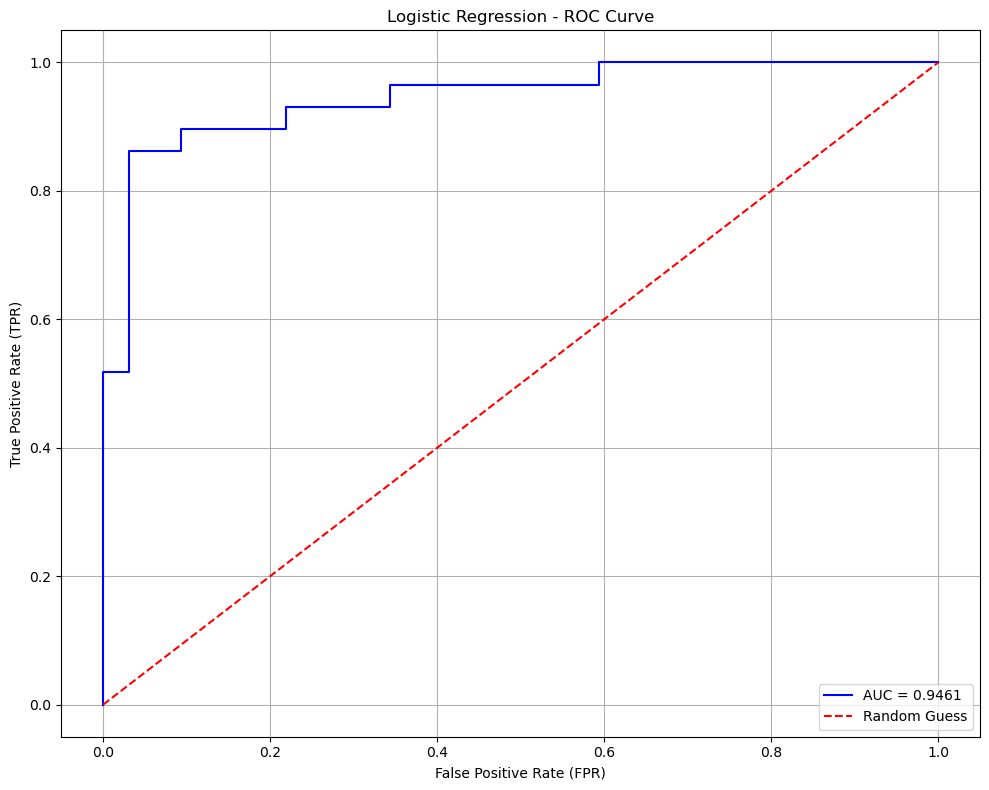

AUC Score: 0.9461


In [2]:
Probabilistic_models.evaluate_logistic_regression(X,y,predictors)


Posterior Mean Coefficients (Rescaled with Uncertainty):
    Bias (Intercept):  6.9309 ±  0.2050
                 Age: -0.0113 ±  0.0263
                 Sex: -1.5813 ±  0.5150
              RestBP: -0.0184 ±  0.0116
                Chol: -0.0087 ±  0.0046
                 Fbs:  0.4225 ±  0.5767
             RestECG: -0.1308 ±  0.1951
               MaxHR:  0.0133 ±  0.0109
               ExAng: -0.7771 ±  0.4442
             Oldpeak: -0.3693 ±  0.2244
               Slope: -0.7610 ±  0.3663
                  Ca: -1.2126 ±  0.2946
ChestPain_nonanginal:  1.4709 ±  0.5070
ChestPain_nontypical:  0.8702 ±  0.5857
   ChestPain_typical:  1.8505 ±  0.6549
         Thal_normal: -0.1660 ±  0.7437
     Thal_reversable: -1.2111 ±  0.7284

Train Accuracy: 0.85

Test Accuracy: 0.87
F1 Score: 0.86
Confusion Matrix:
 [[29  3]
 [ 5 24]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.91      0.88        32
           1       0.89      0.83

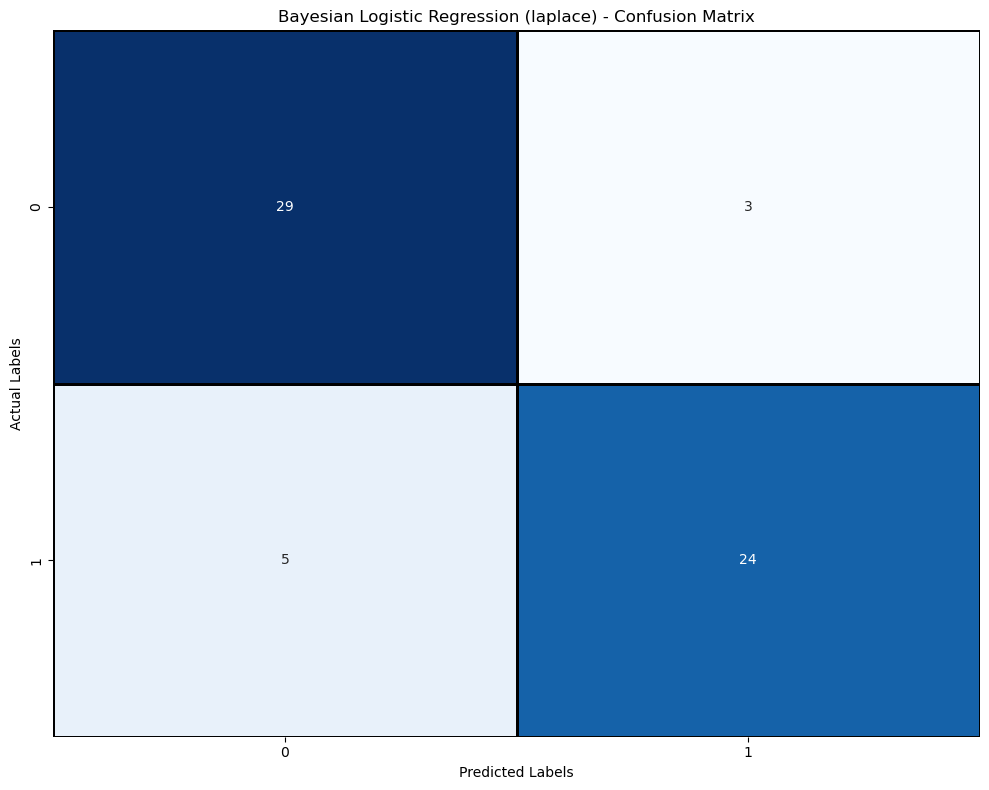

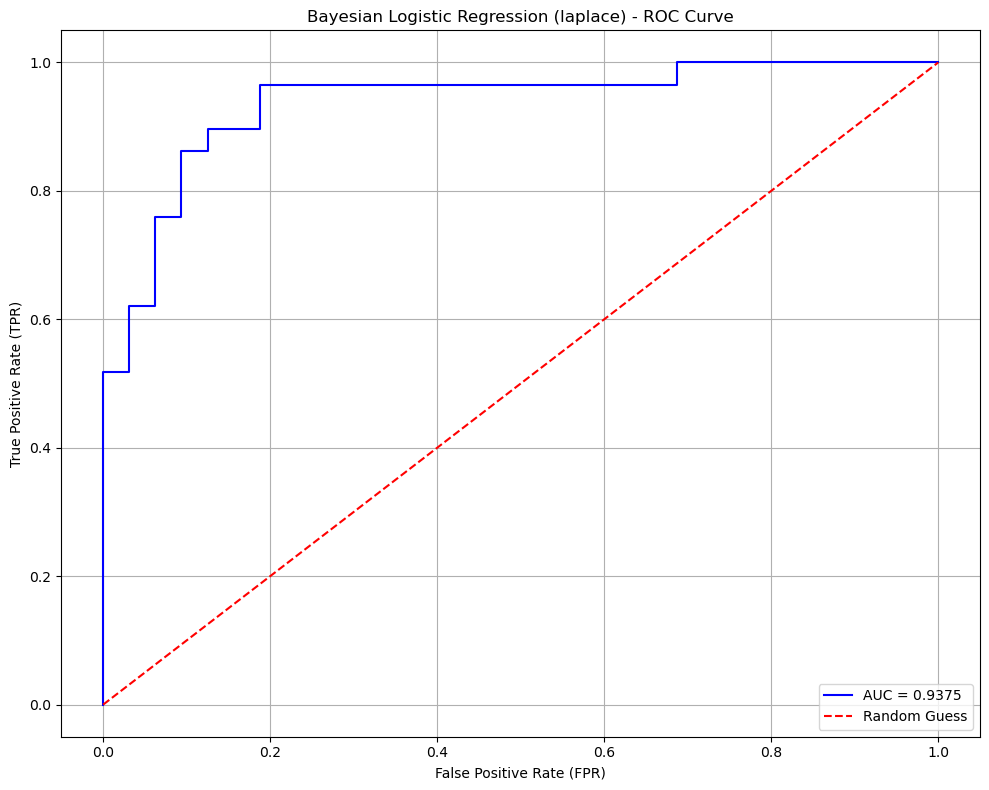

AUC Score: 0.9375


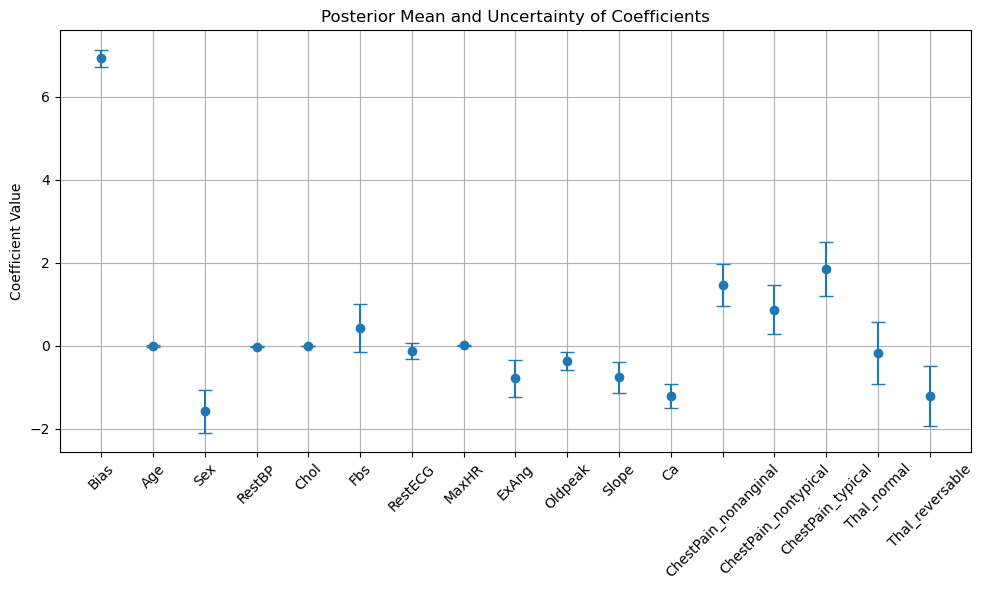

In [3]:
Probabilistic_models.evaluate_bayesian_logistic_regression(X,y,predictors,method='laplace')


Posterior Mean Coefficients (Rescaled with Uncertainty):
    Bias (Intercept):  7.1223 ±  0.1072
                 Age: -0.0120 ±  0.0118
                 Sex: -1.6455 ±  0.2278
              RestBP: -0.0188 ±  0.0059
                Chol: -0.0089 ±  0.0021
                 Fbs:  0.4227 ±  0.2976
             RestECG: -0.1392 ±  0.1056
               MaxHR:  0.0129 ±  0.0047
               ExAng: -0.7515 ±  0.2282
             Oldpeak: -0.3625 ±  0.0938
               Slope: -0.7310 ±  0.1702
                  Ca: -1.2599 ±  0.1209
ChestPain_nonanginal:  1.5336 ±  0.2398
ChestPain_nontypical:  0.8445 ±  0.2830
   ChestPain_typical:  1.8882 ±  0.3682
         Thal_normal: -0.1593 ±  0.2117
     Thal_reversable: -1.1986 ±  0.2177

Train Accuracy: 0.84

Test Accuracy: 0.85
F1 Score: 0.84
Confusion Matrix:
 [[29  3]
 [ 6 23]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87        32
           1       0.88      0.79

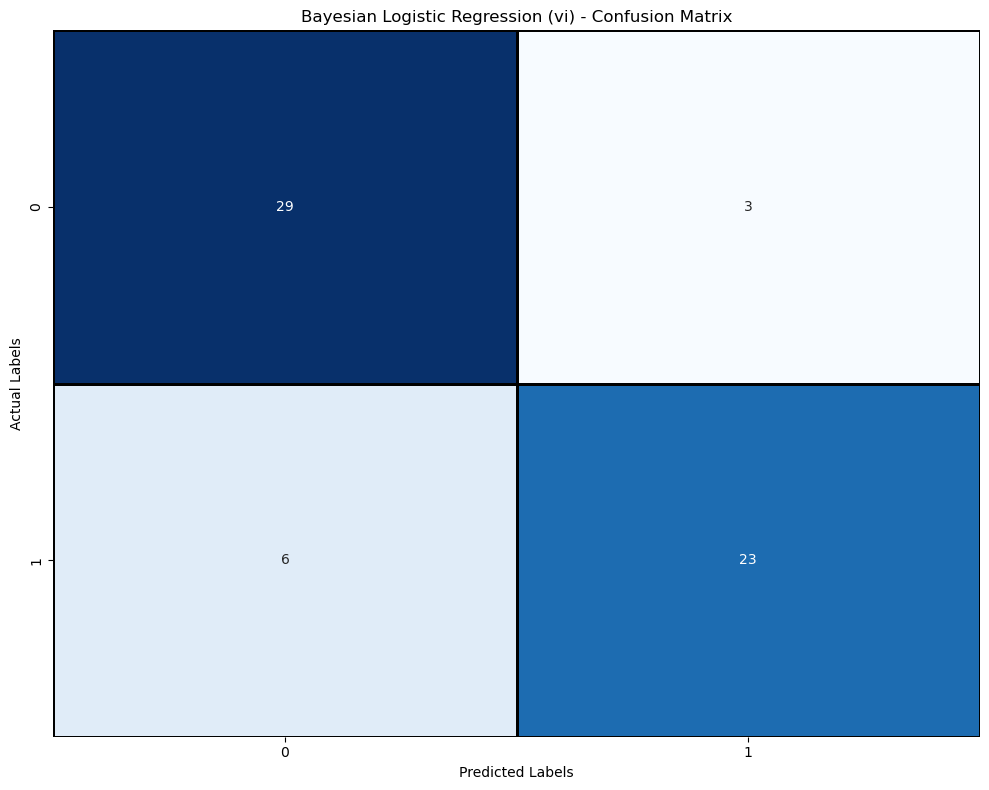

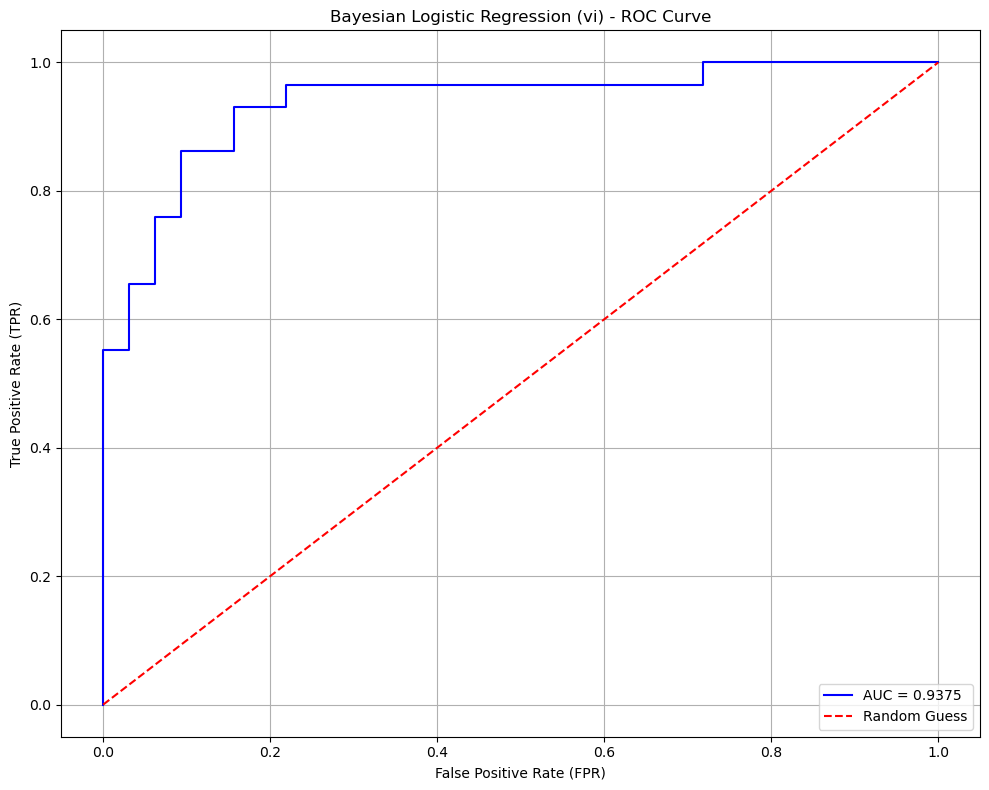

AUC Score: 0.9375


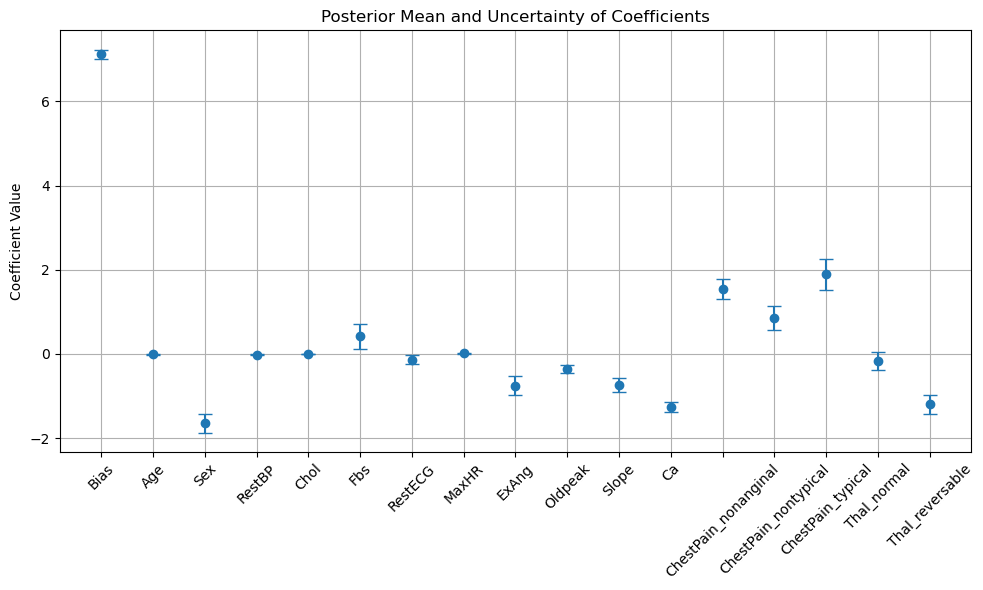

In [4]:
Probabilistic_models.evaluate_bayesian_logistic_regression(X,y,predictors,method='vi')


Posterior Mean Coefficients (Rescaled with Uncertainty):
    Bias (Intercept):  7.5380 ±  0.2002
                 Age: -0.0109 ±  0.0234
                 Sex: -1.7118 ±  0.4417
              RestBP: -0.0207 ±  0.0109
                Chol: -0.0094 ±  0.0044
                 Fbs:  0.5238 ±  0.5484
             RestECG: -0.1591 ±  0.1944
               MaxHR:  0.0145 ±  0.0097
               ExAng: -0.8382 ±  0.4129
             Oldpeak: -0.4127 ±  0.1945
               Slope: -0.8309 ±  0.3208
                  Ca: -1.3273 ±  0.2719
ChestPain_nonanginal:  1.6138 ±  0.4520
ChestPain_nontypical:  0.9295 ±  0.5242
   ChestPain_typical:  2.0609 ±  0.5733
         Thal_normal: -0.1566 ±  0.3884
     Thal_reversable: -1.3164 ±  0.3968

Train Accuracy: 0.85

Test Accuracy: 0.87
F1 Score: 0.86
Confusion Matrix:
 [[29  3]
 [ 5 24]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.91      0.88        32
           1       0.89      0.83

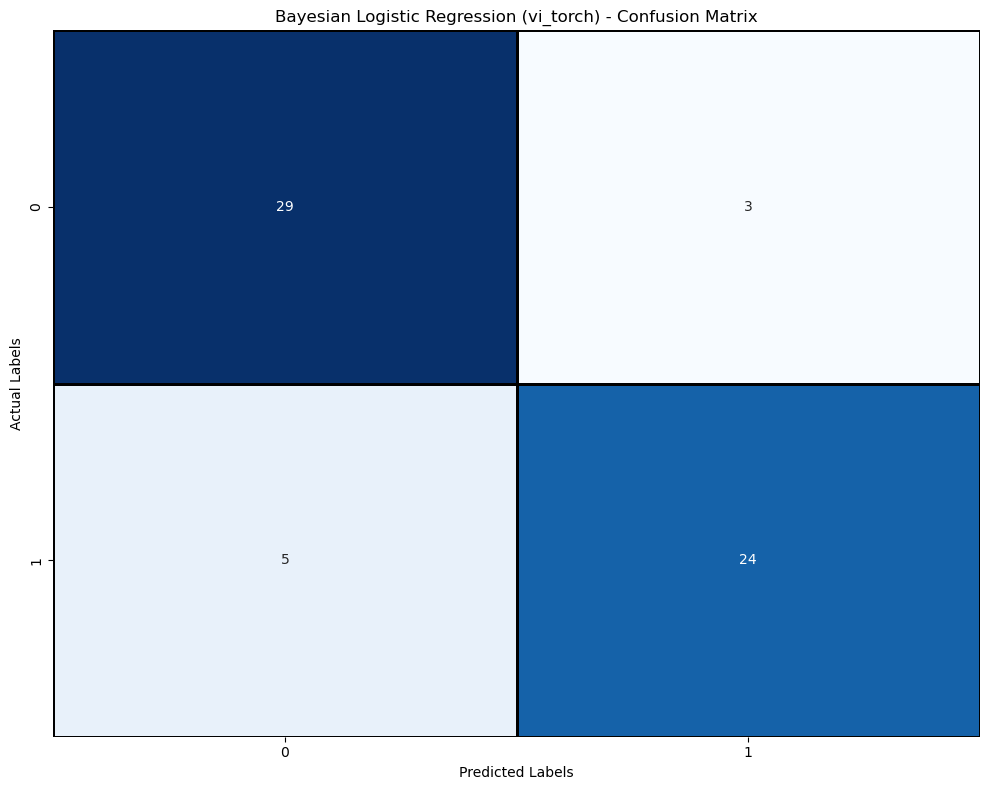

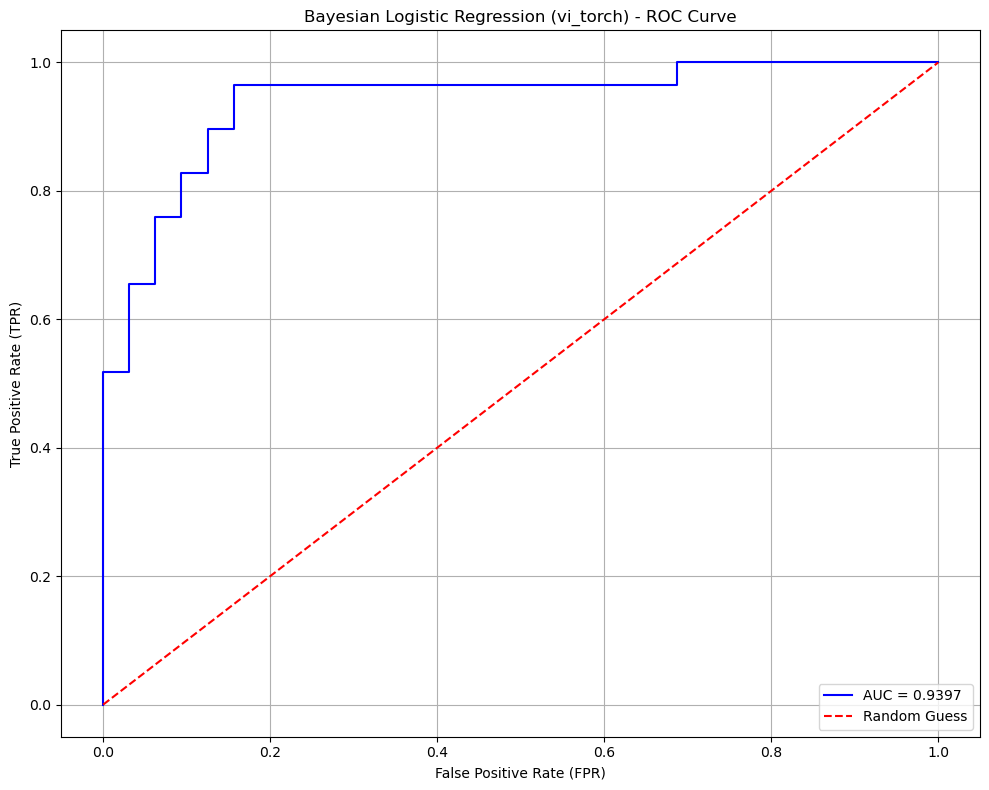

AUC Score: 0.9397


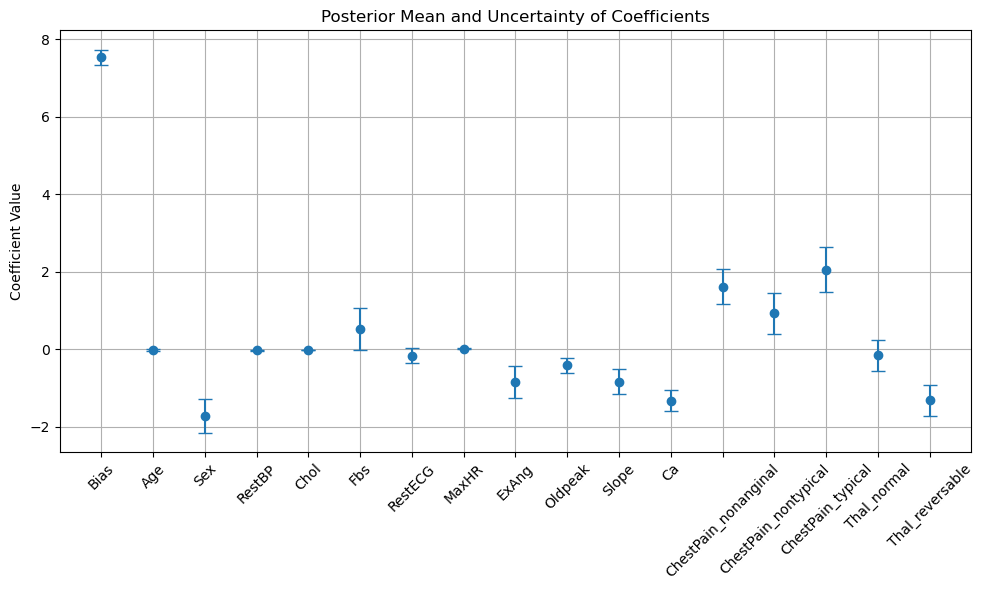

In [5]:
Probabilistic_models.evaluate_bayesian_logistic_regression(X,y,predictors,method='vi_torch')


Posterior Mean Coefficients (Rescaled with Uncertainty):
    Bias (Intercept):  8.0281 ±  0.2287
                 Age: -0.0159 ±  0.0285
                 Sex: -1.7575 ±  0.5623
              RestBP: -0.0203 ±  0.0114
                Chol: -0.0090 ±  0.0047
                 Fbs:  0.6273 ±  0.5430
             RestECG: -0.1578 ±  0.2181
               MaxHR:  0.0128 ±  0.0119
               ExAng: -0.8945 ±  0.4642
             Oldpeak: -0.4226 ±  0.2449
               Slope: -0.8885 ±  0.3990
                  Ca: -1.4293 ±  0.3083
ChestPain_nonanginal:  1.5272 ±  0.5890
ChestPain_nontypical:  0.8245 ±  0.6030
   ChestPain_typical:  2.0619 ±  0.7042
         Thal_normal:  0.0198 ±  0.7805
     Thal_reversable: -1.1196 ±  0.7853

Train Accuracy: 0.85

Test Accuracy: 0.85
F1 Score: 0.84
Confusion Matrix:
 [[29  3]
 [ 6 23]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87        32
           1       0.88      0.79

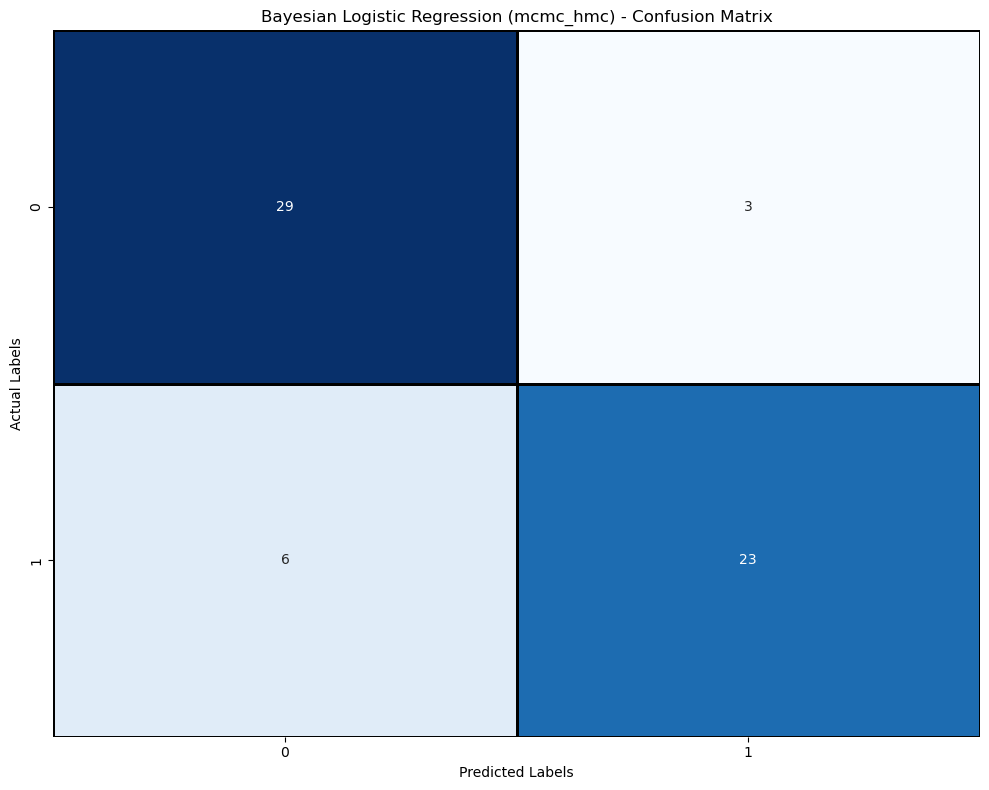

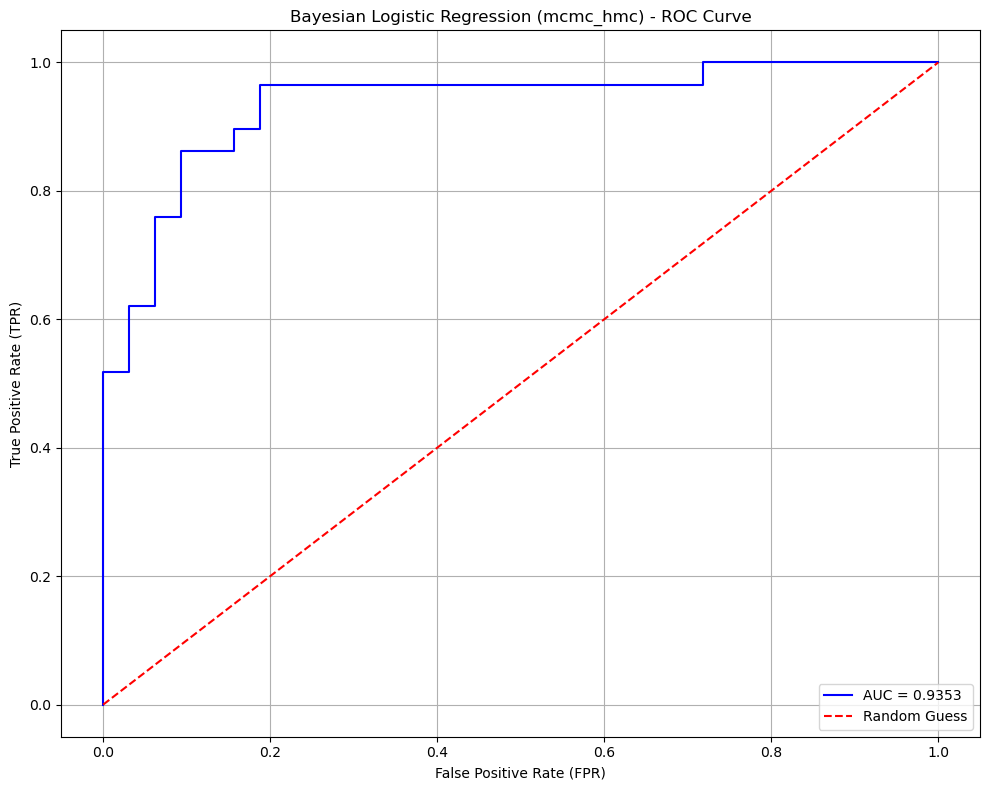

AUC Score: 0.9353


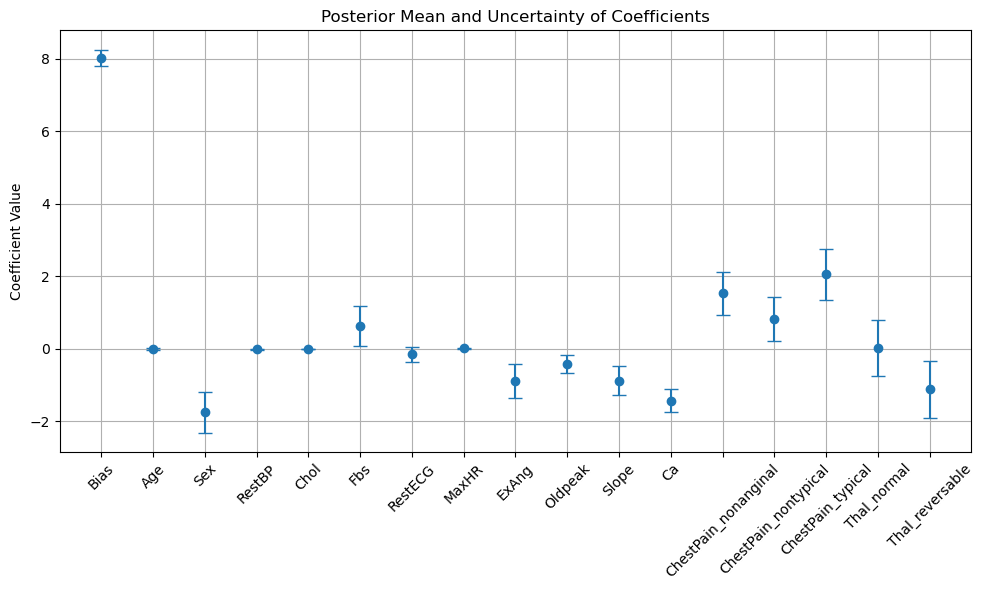

In [6]:
Probabilistic_models.evaluate_bayesian_logistic_regression(X,y,predictors,method='mcmc_hmc')


Posterior Mean Coefficients (Rescaled with Uncertainty):
    Bias (Intercept):  7.3299 ±  0.2000
                 Age: -0.0006 ±  0.0350
                 Sex: -1.3822 ±  0.4888
              RestBP: -0.0255 ±  0.0089
                Chol: -0.0100 ±  0.0056
                 Fbs:  0.7533 ±  0.5343
             RestECG: -0.1980 ±  0.2122
               MaxHR:  0.0083 ±  0.0076
               ExAng: -0.9534 ±  0.4357
             Oldpeak: -0.4338 ±  0.2096
               Slope: -0.6428 ±  0.3072
                  Ca: -1.4766 ±  0.2761
ChestPain_nonanginal:  1.8049 ±  0.6047
ChestPain_nontypical:  1.1455 ±  0.4423
   ChestPain_typical:  2.2076 ±  0.7953
         Thal_normal:  0.9048 ±  0.5330
     Thal_reversable: -0.4856 ±  0.4310

Train Accuracy: 0.84

Test Accuracy: 0.87
F1 Score: 0.86
Confusion Matrix:
 [[29  3]
 [ 5 24]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.91      0.88        32
           1       0.89      0.83

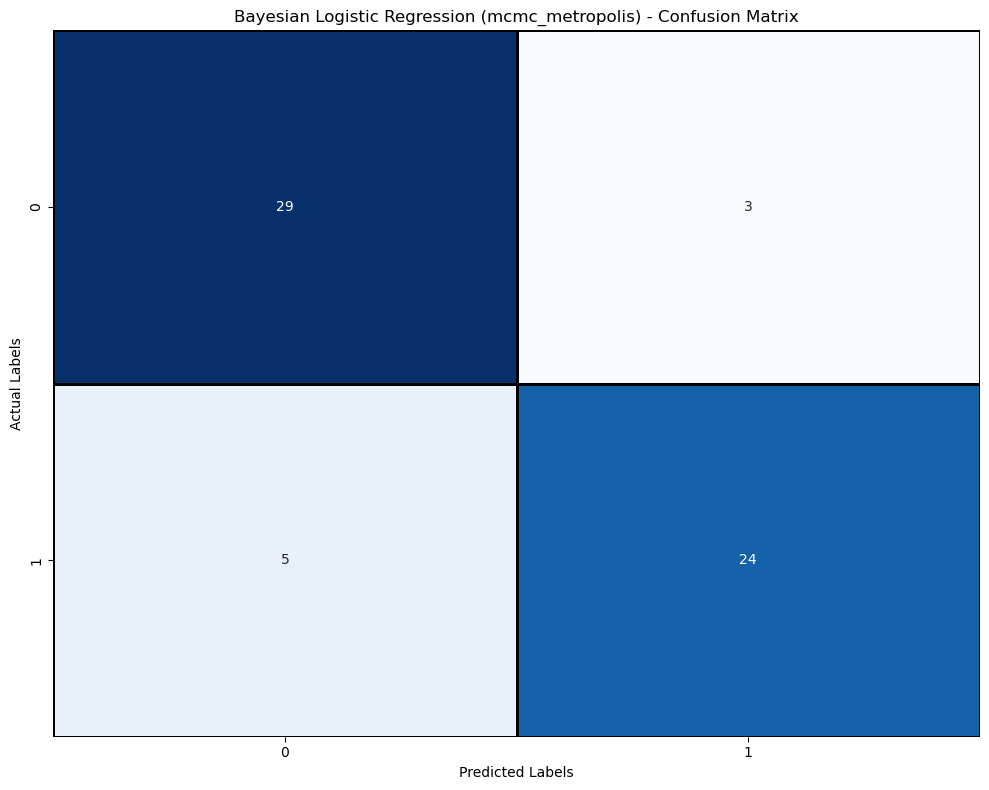

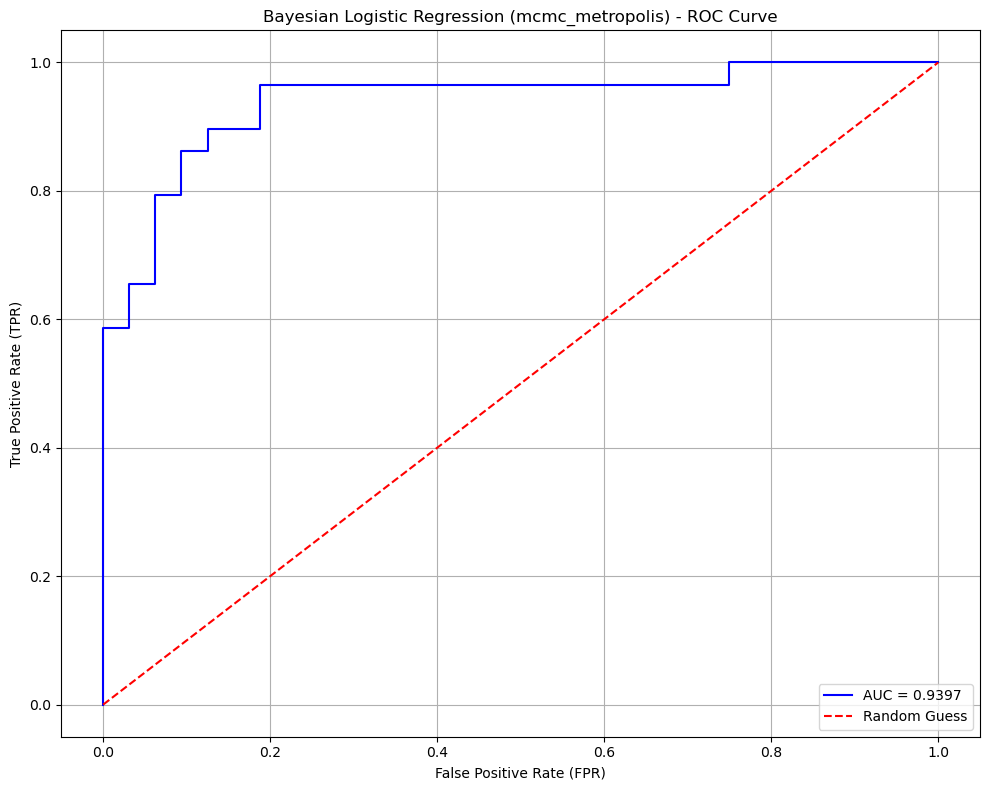

AUC Score: 0.9397


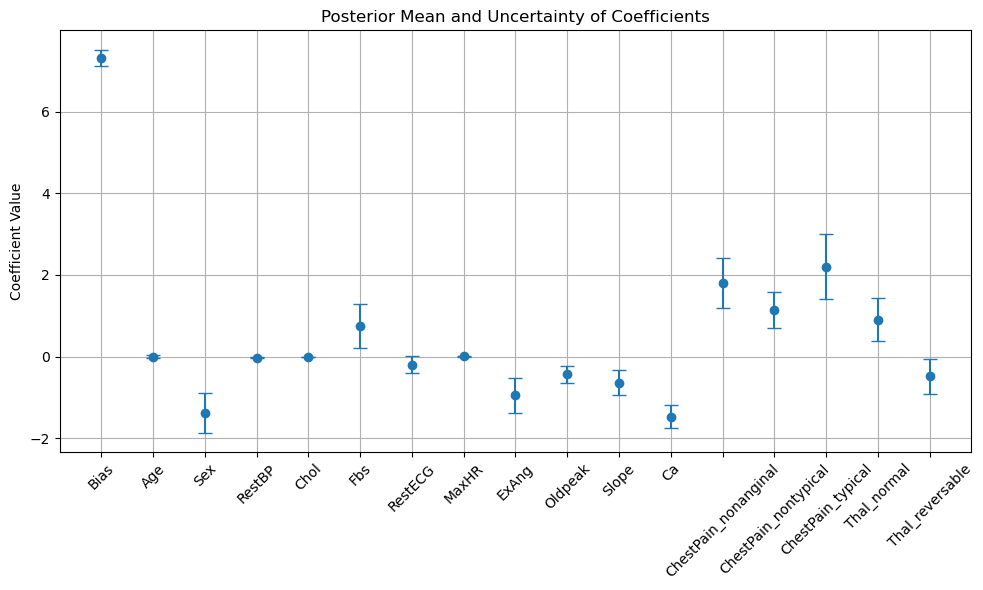

In [7]:
Probabilistic_models.evaluate_bayesian_logistic_regression(X,y,predictors,method='mcmc_metropolis')


Dataset Overview
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

   lstat  medv  
0   4.98  24.0  
1   9.14  21.6  
2   4.03  34.7  
3   2.94  33.4  
4   5.33  36.2  
Shape: (506, 13)

Column Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float6

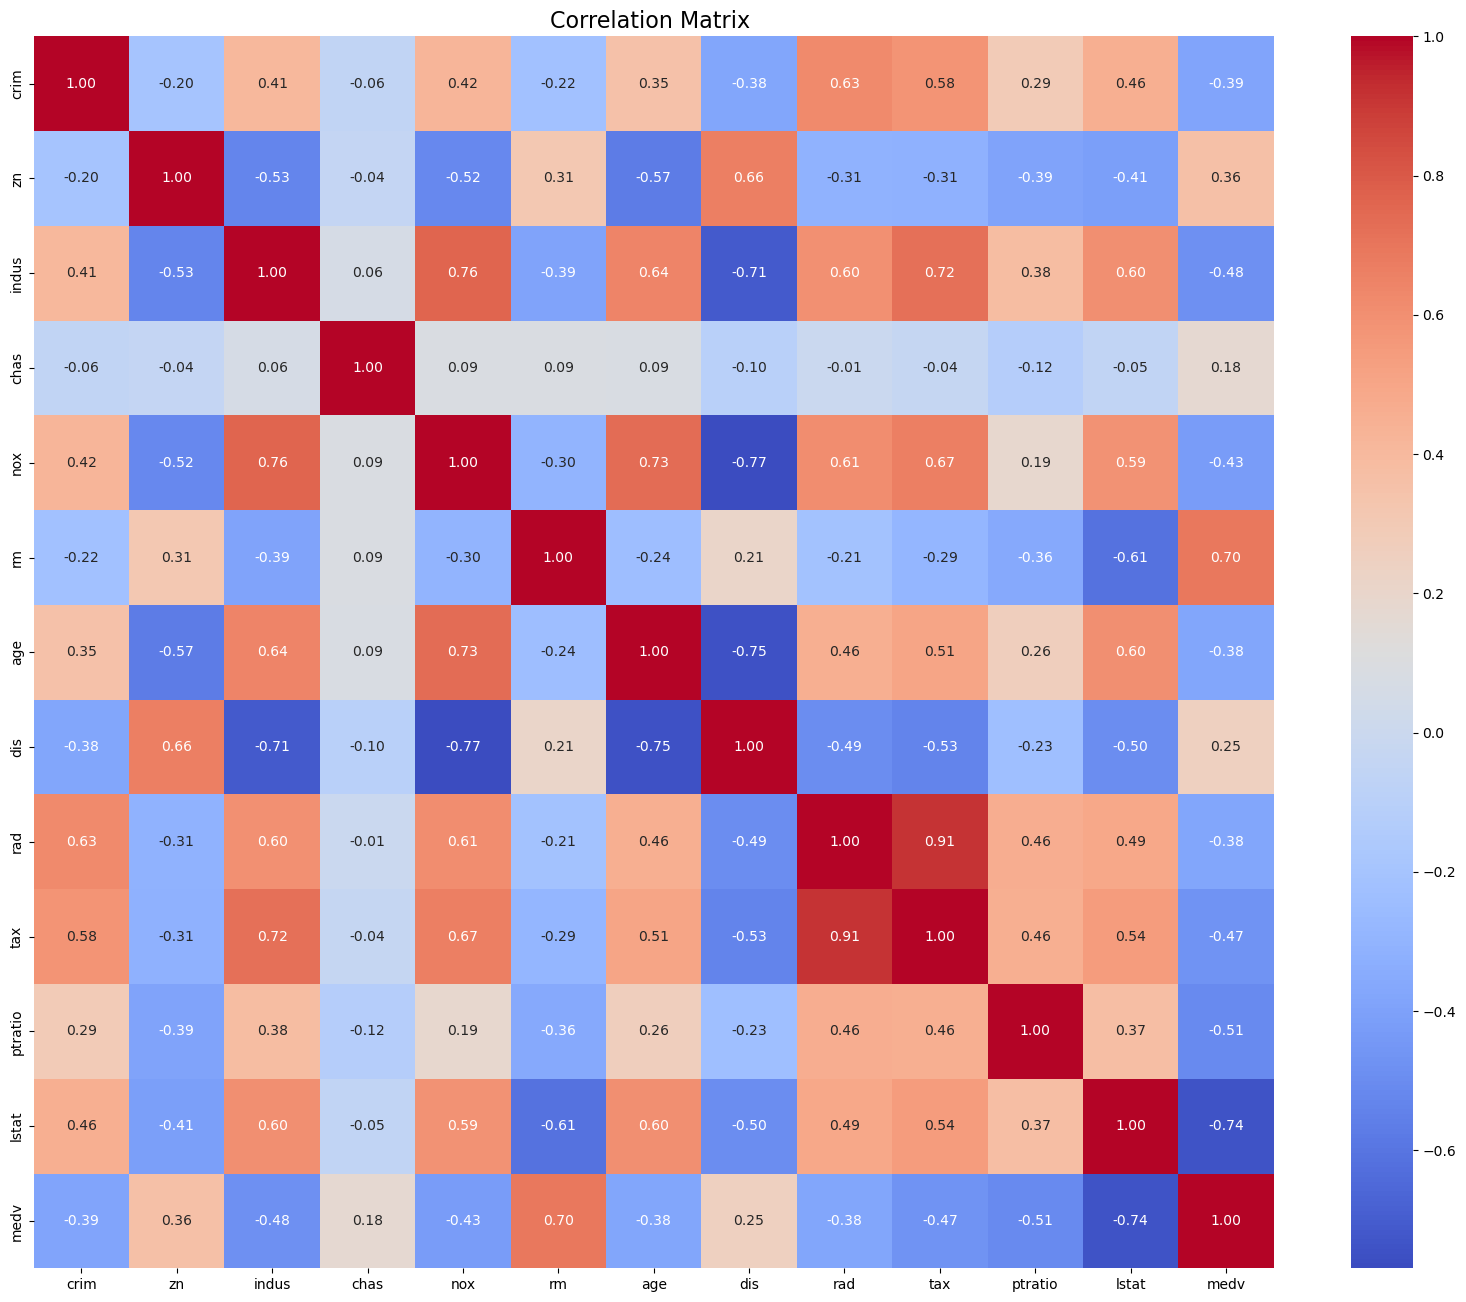


Correlation with Target (response)
medv       1.000000
rm         0.695360
zn         0.360445
dis        0.249929
chas       0.175260
age       -0.376955
rad       -0.381626
crim      -0.388305
nox       -0.427321
tax       -0.468536
indus     -0.483725
ptratio   -0.507787
lstat     -0.737663
Name: medv, dtype: float64

Response Variable: medv
Predictor Variables (12): ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'lstat']


In [8]:
Hitters= pd.read_csv('All Sample Data/Sample Data/Boston.csv')
response='medv'
df=All_Regression_models.EDA_processing(Hitters,response)
# Separate predictors (X) and target (y)    
X = df.drop('medv', axis=1)
y = df['medv']
# Optional: Get list of predictor names
predictors= X.columns.tolist()

Estimated Coefficients :
Intercept : 36.9705
Coefficient for crim : -0.1272
Coefficient for zn : 0.0308
Coefficient for indus : 0.0252
Coefficient for chas : 3.0495
Coefficient for nox : -18.1832
Coefficient for rm : 4.2401
Coefficient for age : -0.0036
Coefficient for dis : -1.4655
Coefficient for rad : 0.2400
Coefficient for tax : -0.0113
Coefficient for ptratio : -0.8948
Coefficient for lstat : -0.5378


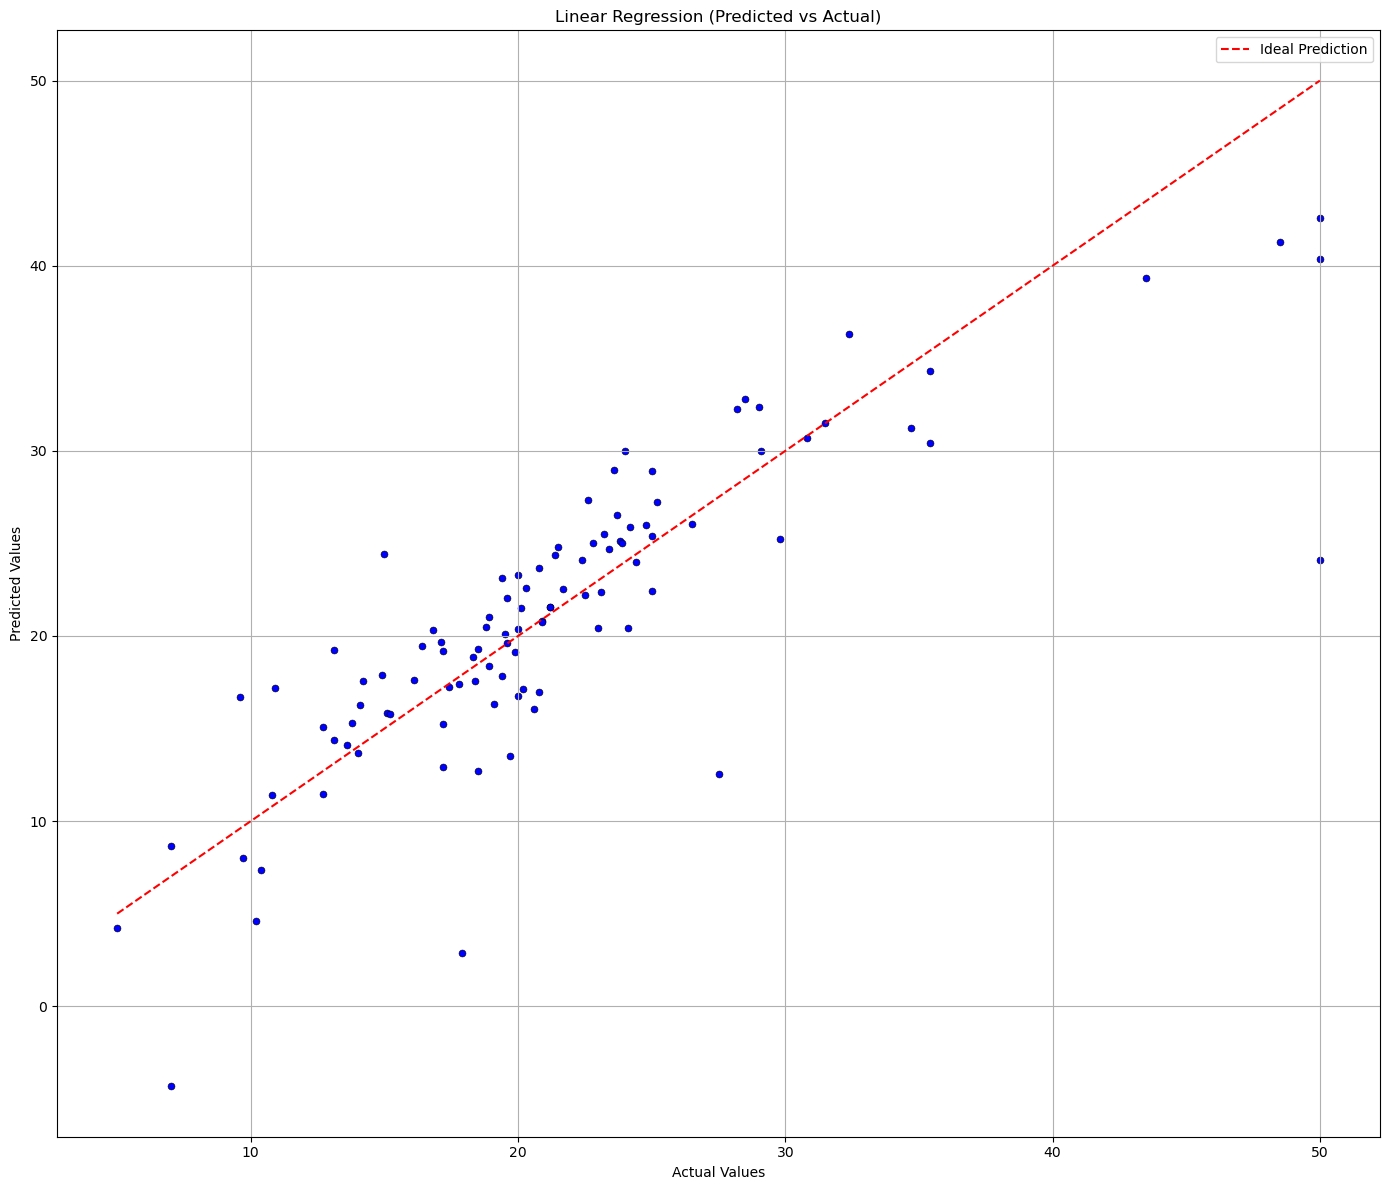

Train RSS : 9132.1317
Test RSS :2323.3263
Train MSE :22.6043
Test MSE :22.7777
Train R^2 :0.74
Test R^2 :0.69
Train Adjusted R^2 :0.73
Test Adjusted R^2 :0.65


In [9]:
All_Regression_models.evaluate_linear_regression(X,y,predictors)


Posterior Mean Coefficients (Rescaled with Uncertainty):
    Bias (Intercept):  36.5430 ±  0.0499
                crim: -0.1261 ±  0.0073
                  zn:  0.0300 ±  0.0034
               indus:  0.0216 ±  0.0141
                chas:  3.0631 ±  0.2011
                 nox: -17.9190 ±  0.8872
                  rm:  4.2517 ±  0.0971
                 age: -0.0037 ±  0.0031
                 dis: -1.4481 ±  0.0474
                 rad:  0.2309 ±  0.0157
                 tax: -0.0108 ±  0.0009
             ptratio: -0.8908 ±  0.0303
               lstat: -0.5356 ±  0.0116

Evaluation Metrics:
RSS (Train): 9132.6760
Train MSE: 22.6056
RSS (Test): 2326.8838
Test MSE: 22.8126
Train R^2: 0.7398
Test R^2: 0.6889


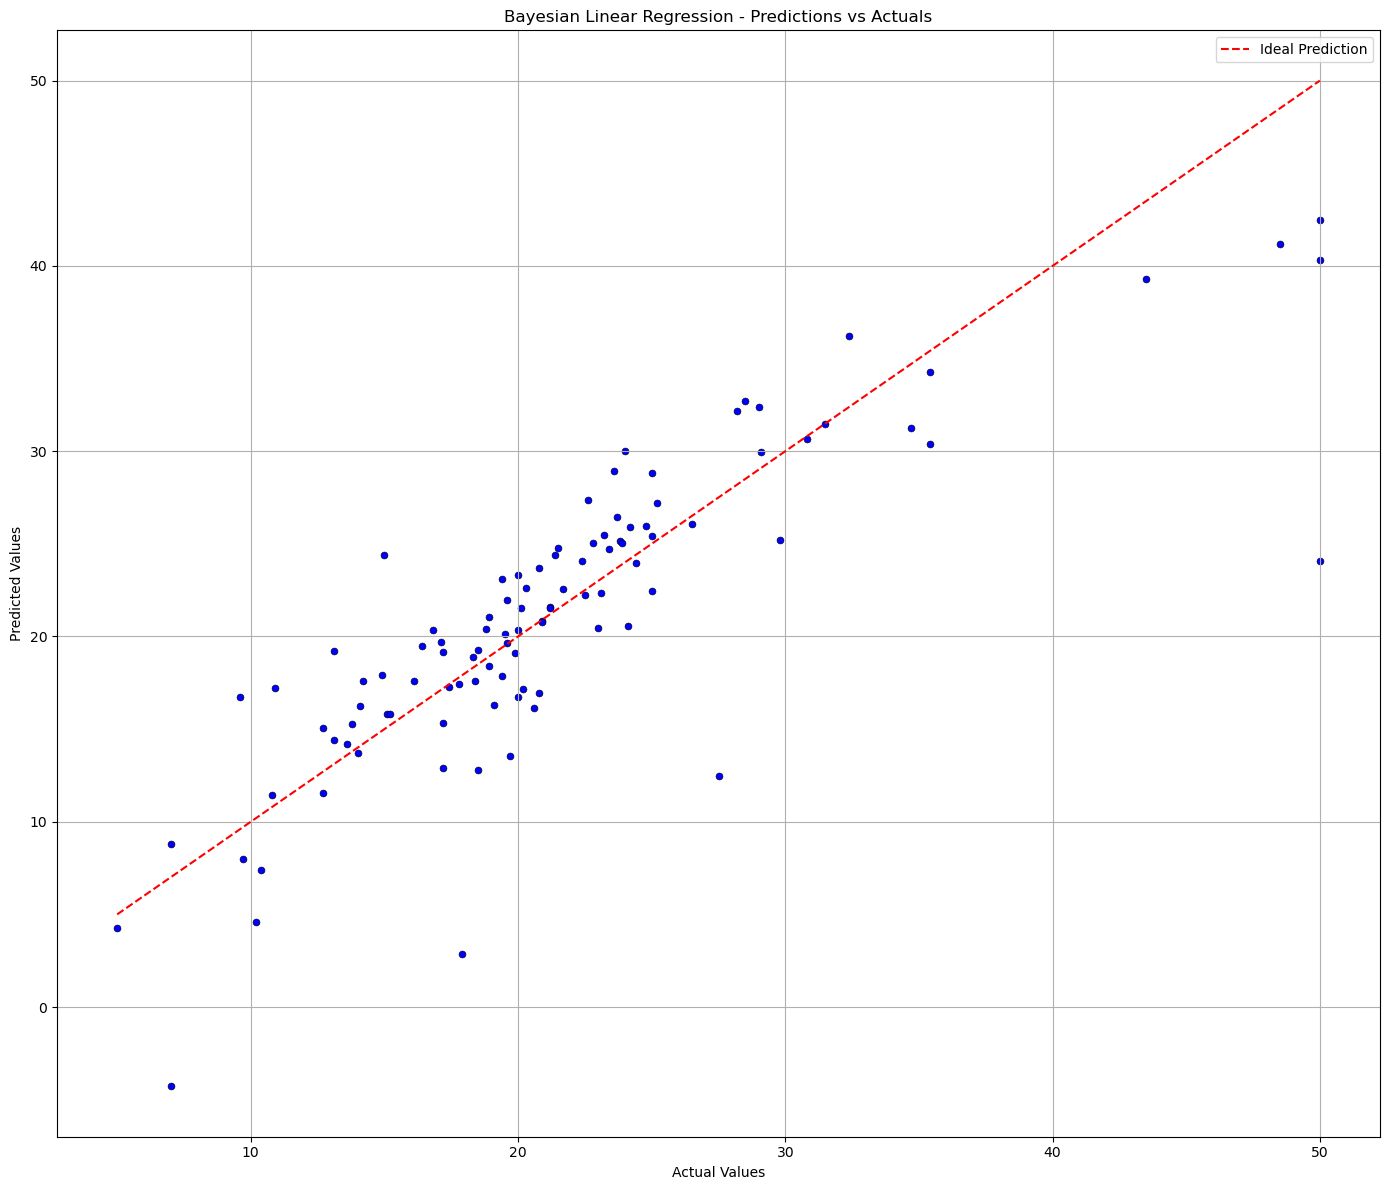

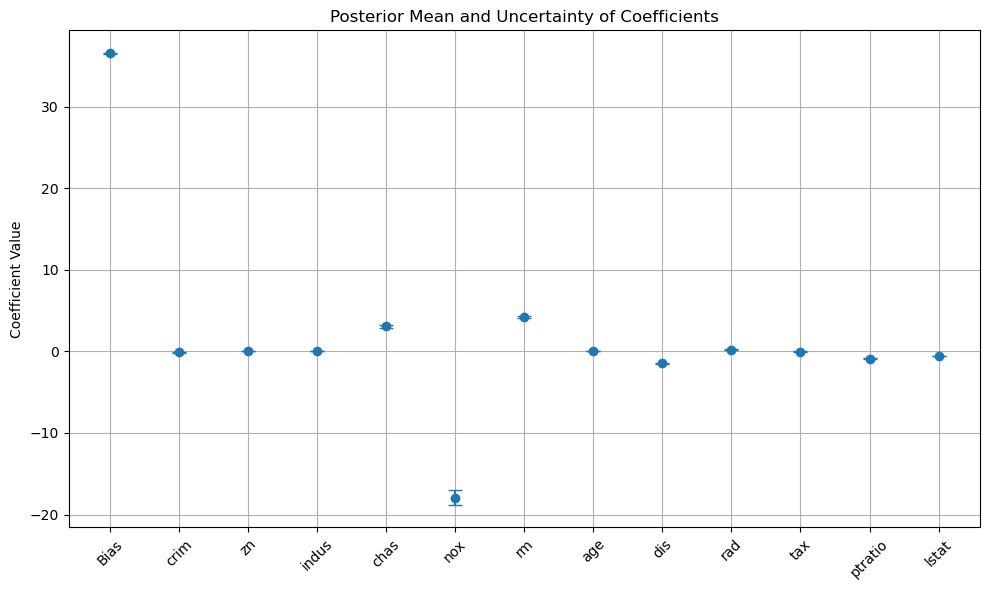

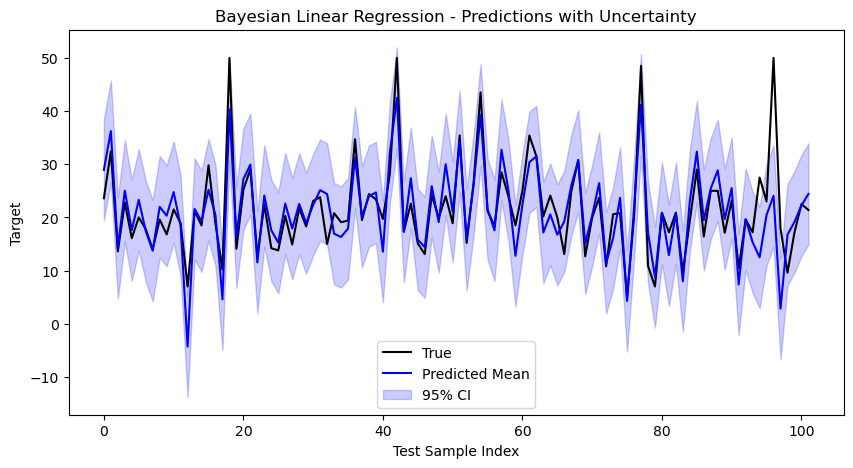

In [10]:
Probabilistic_models.evaluate_bayesian_linear_regression(X,y,predictors)